In [1]:
from matplotlib import pyplot as plt
import json
import numpy as np

In [ ]:
# k-clique solution probability with graph density p
def plot_success_prob_for_var(filename, var_names, title=None, plots=["found_solution"], fig_filename=None, interpret_metric=None, interpret_solution=None):
    with open(filename, "r") as f:
        benchmark_results = json.load(f)

    # print(benchmark_results)

    plt.figure()
    if title:
        plt.title(title)
    w = 0.4
    num_problem_sizes = len(benchmark_results["problem_sizes"])
    main_var = np.unique(np.array([s[var_names[0]] for s in benchmark_results["problem_sizes"]]))
    if len(var_names) > 1:
        second_var = np.array(list(set([s[var_names[1]] for s in benchmark_results["problem_sizes"]])))
    # num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
    # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
    plt.ylabel("%")
    plt.xlabel(var_names[0])
    for i, plot in enumerate(plots):
        if len(var_names) > 1:
            for sv in second_var:
                found_solutions = [sum([g[plot] for g in s]) for i,s in enumerate(benchmark_results["results_per_size"]) if benchmark_results["problem_sizes"][i][var_names[1]] == sv]
                if interpret_metric == None or interpret_metric[i] == "per_graph":
                    normalization = benchmark_results["num_graphs"]
                elif interpret_metric[i] == "per_iter":
                    normalization = benchmark_results["num_graphs"] * np.array([ s["iters_per_graph"] for s in benchmark_results["problem_sizes"] if s[var_names[1]] == sv])
                plt.plot(main_var, np.array(found_solutions) / normalization, label=f"{var_names[1]}={sv}")
        else:
            if interpret_metric == None or interpret_metric[i] == "per_graph":
                normalization = benchmark_results["num_graphs"]
            elif interpret_metric[i] == "per_iter":
                normalization = benchmark_results["num_graphs"] * np.array([s["iters_per_graph"] for s in benchmark_results["problem_sizes"]])
            if interpret_solution == None or interpret_solution[i] == "number":
                found_solutions = [sum([g[plot] for g in s]) for s in benchmark_results["results_per_size"]]
            elif interpret_solution[i] == "not_zero":
                found_solutions = [sum([g[plot] > 0 for g in s]) for s in benchmark_results["results_per_size"]]
            plt.plot(main_var, np.array(found_solutions) / normalization, label=plot)
    # if "valid_cliques" in plots:
    #     valid_cliques = np.array([sum([g["valid_cliques"] > 0 for g in s]) for s in benchmark_results["results_per_size"]])
    #     plt.plot(main_var, np.array(valid_cliques) / benchmark_results["num_graphs"]-0.01, label=f"valid cliques")
    plt.grid()
    plt.ylim(0, 1.05)
    plt.legend()
    if fig_filename:
        plt.savefig(fig_filename)
    plt.show()
# plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p.json", ["p"], "Max-clique QAOA Solutions for different p", plots=["found_solution", "valid_cliques"])

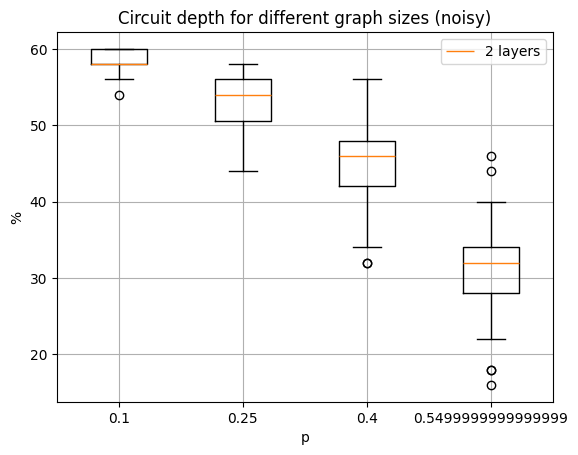

In [4]:
# k-clique solution probability with graph density p
def plot_circuit_infos(filename, var_names, title=None, plots=["depths_per_size"], fig_filename=None):
    with open(filename, "r") as f:
        benchmark_results = json.load(f)

    # print(benchmark_results)

    plt.figure()
    if title:
        plt.title(title)
    w = 0.4
    # num_problem_sizes = len(benchmark_results["problem_sizes"])
    problem_size_var = np.array([s[var_names[0]] for s in benchmark_results["problem_sizes"]])
    # num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
    num_graphs = benchmark_results
    # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
    plt.ylabel("%")
    plt.xlabel(var_names[0])
    if "depths_per_size" in plots:
        depths = benchmark_results["depths_per_size"]
        plt.boxplot(depths, showfliers=True, label="2 layers")
    plt.xticks(np.arange(1, len(problem_size_var)+1), problem_size_var)
    plt.grid()
    # plt.ylim(0, 1.05)
    plt.legend()
    if fig_filename:
        plt.savefig(fig_filename)
    plt.show()

plot_circuit_infos("benchmarkResults/qaoa_results_maxclique_p.json", ["p"], "Circuit depth for different graph sizes (noisy)", plots=["depths_per_size"])

{'problem_sizes': [{'n': 6, 'p': 0.4, 'k': 2, 'iters_per_graph': 10, 'layers': 4}, {'n': 10, 'p': 0.4, 'k': 4, 'iters_per_graph': 10, 'layers': 4}, {'n': 14, 'p': 0.4, 'k': 4, 'iters_per_graph': 10, 'layers': 4}], 'num_graphs': 5, 'layers': 4, 'results_per_size': [[{'valid_cliques': 7, 'k_cliques': 7, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 3, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 3, 'found_solution': True}, {'valid_cliques': 4, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 4, 'found_solution': True}], [{'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 2, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 3, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}], [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'foun

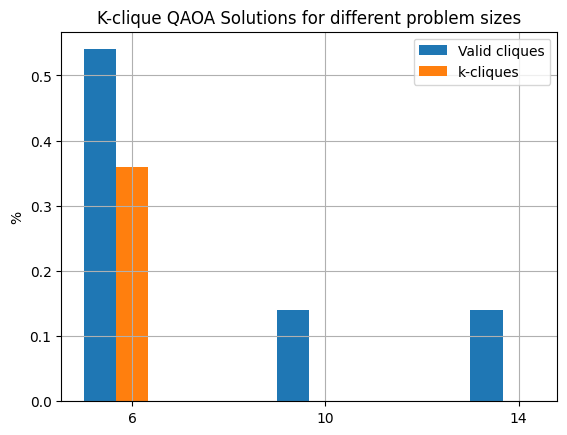

In [12]:
# k-clique problem sizes
with open("benchmarkResults/qaoa_results_kclique_n.json", "r") as f:
    benchmark_graph_size_results = json.load(f)

print(benchmark_graph_size_results)
valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_graph_size_results["results_per_size"]]
k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_graph_size_results["results_per_size"]]
found_solutions_sizes = [sum([g["found_solution"] for g in s]) for s in benchmark_graph_size_results["results_per_size"]]
print(valid_cliques_k_clique_sizes)
print(k_cliques_sizes)
print(found_solutions_sizes)

plt.figure()
plt.title("K-clique QAOA Solutions for different problem sizes")
w = 0.5
num_tests_sizes = benchmark_graph_size_results["num_graphs"] * np.array([s["iters_per_graph"] for s in benchmark_graph_size_results["problem_sizes"]])
num_problem_sizes = len(benchmark_graph_size_results["problem_sizes"])
plt.xticks(np.arange(num_problem_sizes), [s["n"] for s in benchmark_graph_size_results["problem_sizes"]])
plt.ylabel("%")
plt.bar(np.arange(num_problem_sizes) - w/3, np.array(valid_cliques_k_clique_sizes) / num_tests_sizes, width=w/3, label="Valid cliques")
plt.bar(np.arange(num_problem_sizes), np.array(k_cliques_sizes) / num_tests_sizes, width=w/3, label="k-cliques")
# plt.bar(np.arange(num_problem_sizes) + w/3, np.array(found_solutions_sizes) / benchmark_graph_size_results["num_graphs"] , width=w/3, label=f"found solutions \n(iters={benchmark_graph_size_results["iters_per_graph"]})")
plt.grid()
plt.legend()
plt.show()

{'problem_sizes': [{'n': 12, 'p': 0.4, 'k': 4, 'iters_per_graph': 10, 'layers': 4}, {'n': 12, 'p': 0.4, 'k': 4, 'iters_per_graph': 18, 'layers': 4}, {'n': 12, 'p': 0.4, 'k': 4, 'iters_per_graph': 26, 'layers': 4}, {'n': 12, 'p': 0.4, 'k': 4, 'iters_per_graph': 34, 'layers': 4}, {'n': 12, 'p': 0.4, 'k': 4, 'iters_per_graph': 42, 'layers': 4}], 'num_graphs': 40, 'layers': 4, 'results_per_size': [[{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 2, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 3, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0

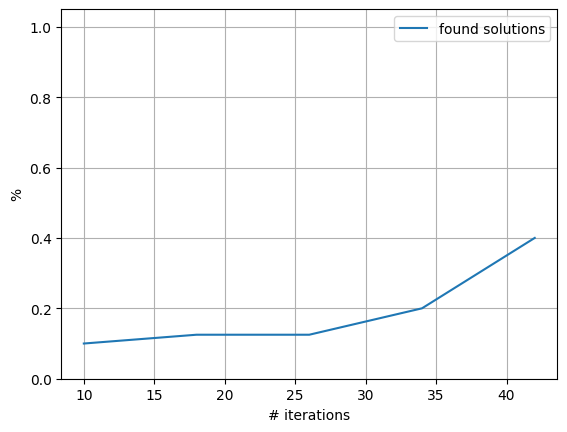

In [23]:
# k-clique solution probability with iteration count
with open("benchmarkResults/qaoa_results_kclique_iters.json", "r") as f:
    benchmark_results = json.load(f)

print(benchmark_results)
# valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
found_solutions = [sum([g["found_solution"] for g in s]) for s in benchmark_results["results_per_size"]]

plt.figure()
# plt.title("K-clique QAOA Solutions for different problem sizes")
w = 0.4
num_problem_sizes = len(benchmark_results["problem_sizes"])
iters_per_graph = np.array([s["iters_per_graph"] for s in benchmark_results["problem_sizes"]])
num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
# plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
plt.ylabel("%")
plt.xlabel("# iterations")
plt.plot(iters_per_graph, np.array(found_solutions) / benchmark_results["num_graphs"], label=f"found solutions")
plt.grid()
plt.ylim(0, 1.05)
plt.legend()
plt.show()

{'problem_sizes': [{'n': 6, 'p': 0.4, 'k': 2, 'iters_per_graph': 10, 'layers': 1}, {'n': 10, 'p': 0.4, 'k': 4, 'iters_per_graph': 25, 'layers': 1}, {'n': 6, 'p': 0.4, 'k': 2, 'iters_per_graph': 10, 'layers': 2}, {'n': 10, 'p': 0.4, 'k': 4, 'iters_per_graph': 25, 'layers': 2}, {'n': 6, 'p': 0.4, 'k': 2, 'iters_per_graph': 10, 'layers': 3}, {'n': 10, 'p': 0.4, 'k': 4, 'iters_per_graph': 25, 'layers': 3}, {'n': 6, 'p': 0.4, 'k': 2, 'iters_per_graph': 10, 'layers': 4}, {'n': 10, 'p': 0.4, 'k': 4, 'iters_per_graph': 25, 'layers': 4}], 'num_graphs': 40, 'results_per_size': [[{'valid_cliques': 8, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 6, 'k_cliques': 3, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 2, 'found_solutio

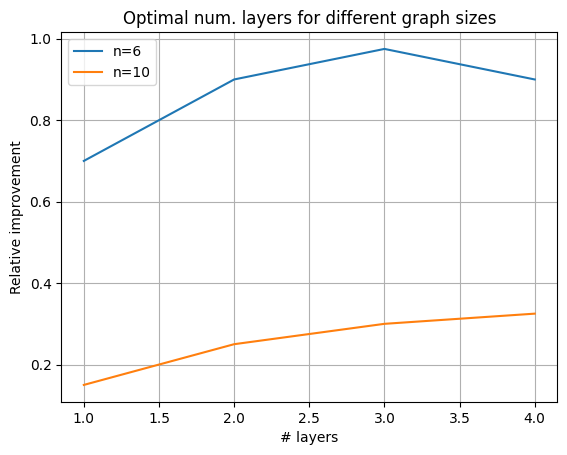

In [58]:
# qaoa k-clique solution probability with different layers and graph sizes
with open("benchmarkResults/qaoa_results_kclique_layers_n.json", "r") as f:
    benchmark_results = json.load(f)

print(benchmark_results)
# valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
found_solutions_per_n = []
problem_sizes_per_n = dict()
problem_sizes_per_n_indices = dict()
for i, size in enumerate(benchmark_results["problem_sizes"]):
    print(size)
    if size["n"] not in problem_sizes_per_n:
        problem_sizes_per_n[size["n"]] = []
        problem_sizes_per_n_indices[size["n"]] = []
    problem_sizes_per_n[size["n"]].append(size["layers"])
    problem_sizes_per_n_indices[size["n"]].append(i)

print(problem_sizes_per_n)
plt.figure()
plt.title("Optimal num. layers for different graph sizes")
w = 0.4
num_problem_sizes = len(benchmark_results["problem_sizes"])
iters_per_graph = benchmark_results["problem_sizes"][0]["iters_per_graph"]
num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
# plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
plt.ylabel("Relative improvement")
plt.xlabel("# layers")
for n in problem_sizes_per_n.keys():
    found_solutions = [sum([g["found_solution"] for g in s]) for s in [s2 for i,s2 in enumerate(benchmark_results["results_per_size"]) if i in problem_sizes_per_n_indices[n]]]
    layers = [benchmark_results["problem_sizes"][i]["layers"] for i in problem_sizes_per_n_indices[n]]
    print(found_solutions)
    print(layers)
    # plt.plot(layers, (np.array(found_solutions) / benchmark_results["num_graphs"]) / (found_solutions[0] / benchmark_results["num_graphs"]), label=f"n={n}") # relative to layer 1
    plt.plot(layers, (np.array(found_solutions) / benchmark_results["num_graphs"]), label=f"n={n}")
plt.grid()
# plt.ylim(0.7, 2)
plt.legend()
plt.savefig("Figures/qaoa_kclique_layers_n.png")
plt.show()

[0.1 0.2 0.3 0.4 0.5 0.6 0.7]
[0.1 0.2 0.3 0.4 0.5 0.6 0.7]


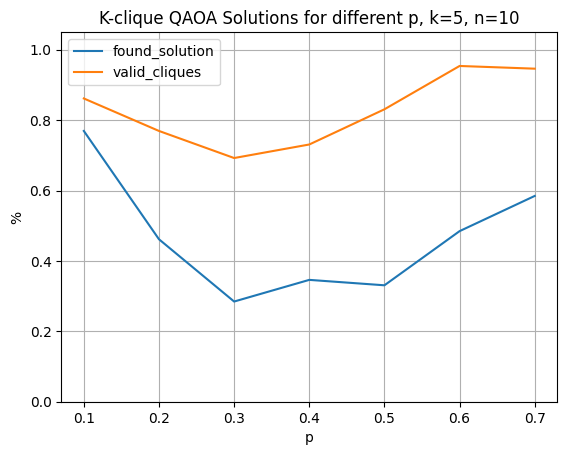

[0.1 0.3 0.5 0.7]
[0.1 0.3 0.5 0.7]


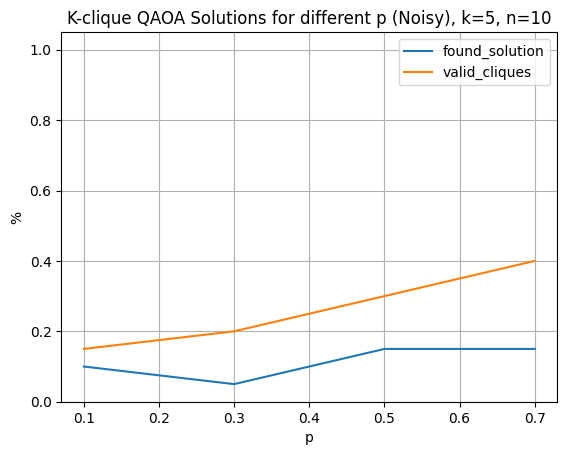

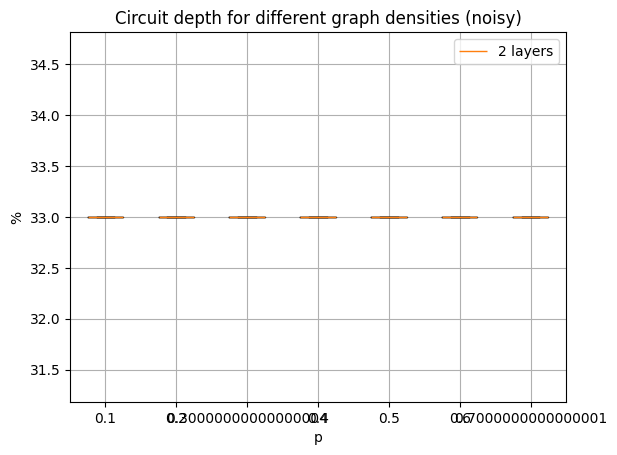

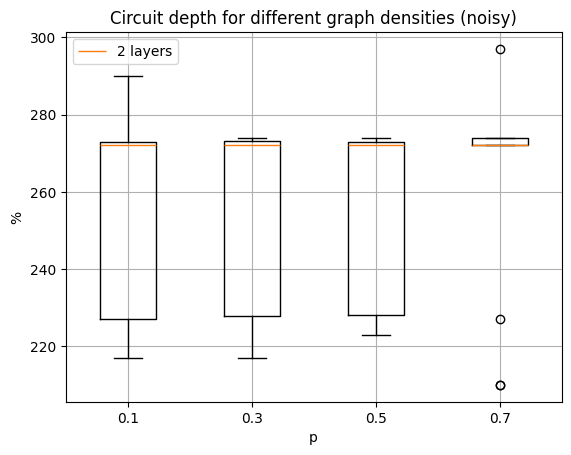

In [23]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_p.json", ["p"], "K-clique QAOA Solutions for different p, k=5, n=10", 
                          plots=["found_solution", "valid_cliques"], interpret_metric=["per_graph", "per_graph"], interpret_solution=["not_zero", "not_zero"],
                          fig_filename="Figures/qaoa_kclique_p")
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_p_noisy.json", ["p"], "K-clique QAOA Solutions for different p (Noisy), k=5, n=10", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_kclique_p_noisy")
plot_circuit_infos("benchmarkResults/qaoa_results_kclique_p.json", ["p"], "Circuit depth for different graph densities (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_kclique_p_depth")
# noisy
plot_circuit_infos("benchmarkResults/qaoa_results_kclique_p_noisy.json", ["p"], "Circuit depth for different graph densities (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_kclique_p_depth_noisy")

[2 3 4 5 6 7 8]
[2 3 4 5 6 7 8]


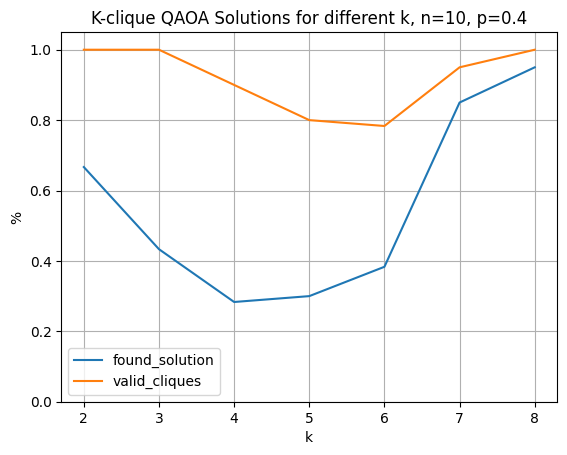

In [134]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_k.json", ["k"], "K-clique QAOA Solutions for different k, n=10, p=0.4", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_kclique_k")

## MAX-Clique

[ 6  8 10 12 14 15 16]
[ 6  8 10 12 14 15 16]


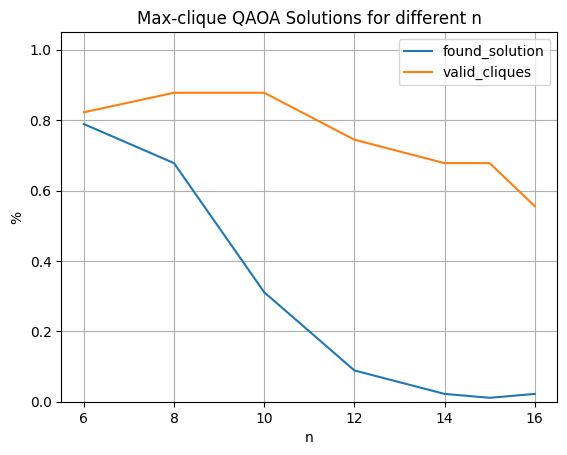

[5 7 9]
[5 7 9]


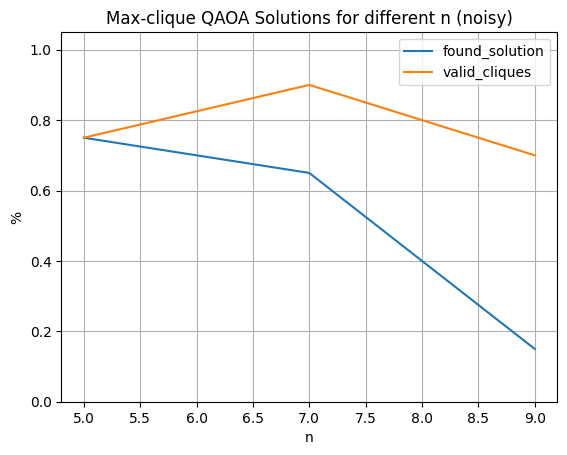

In [135]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_n_oneiter.json", ["n"], "Max-clique QAOA Solutions for different n", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_maxclique_n")
# noisy optimizer
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_n_noisy.json", ["n"], "Max-clique QAOA Solutions for different n (noisy)", plots=["found_solution", "valid_cliques"], fig_filename="Figures/qaoa_maxclique_n_noisy")

[ 1  4  7 10 13 16 19]
[ 1  4  7 10 13 16 19]


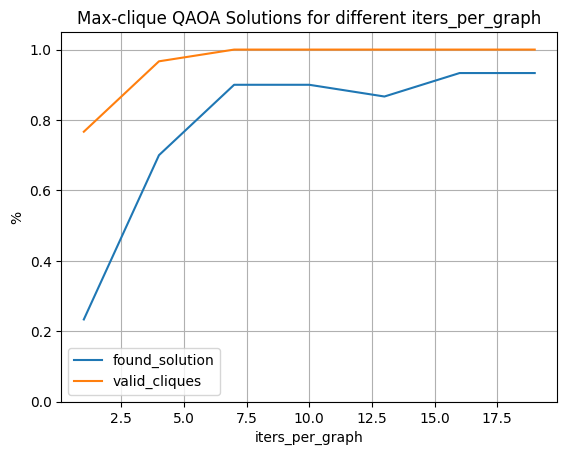

In [136]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_iters.json", ["iters_per_graph"], "Max-clique QAOA Solutions for different iters_per_graph", plots=["found_solution", "valid_cliques"], fig_filename="Figures/qaoa_maxclique_iters")

In [87]:
# # qaoa k-clique solution probability with different layers and graph sizes
# with open("benchmarkResults/qaoa_results_maxclique_layers_n.json", "r") as f:
#     benchmark_results = json.load(f)

# # valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# # k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# found_solutions_per_n = []
# problem_sizes_per_n = dict()
# problem_sizes_per_n_indices = dict()
# for i, size in enumerate(benchmark_results["problem_sizes"]):
#     print(size)
#     if size["n"] not in problem_sizes_per_n:
#         problem_sizes_per_n[size["n"]] = []
#         problem_sizes_per_n_indices[size["n"]] = []
#     problem_sizes_per_n[size["n"]].append(size["layers"])
#     problem_sizes_per_n_indices[size["n"]].append(i)

# print(benchmark_results["num_graphs"])
# plt.figure()
# plt.title("Max-clique Optimal num. layers for different graph sizes")
# w = 0.4
# # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
# plt.ylabel("Relative improvement")
# plt.xlabel("# layers")
# for n in problem_sizes_per_n.keys():
#     found_solutions = [sum([g["found_solution"] for g in s]) for s in [s2 for i,s2 in enumerate(benchmark_results["results_per_size"]) if i in problem_sizes_per_n_indices[n]]]
#     layers = [benchmark_results["problem_sizes"][i]["layers"] for i in problem_sizes_per_n_indices[n]]
#     print(found_solutions)
#     # print(layers)
#     # plt.plot(layers, (np.array(found_solutions) / benchmark_results["num_graphs"]) / (found_solutions[0] / benchmark_results["num_graphs"]), label=f"n={n}") # relative to layer 1
#     plt.plot(layers, (np.array(found_solutions) / benchmark_results["num_graphs"]), label=f"n={n}")
# plt.grid()
# # plt.ylim(0.7, 2)
# plt.ylim(0.0, 1.05)
# plt.legend()
# plt.show()

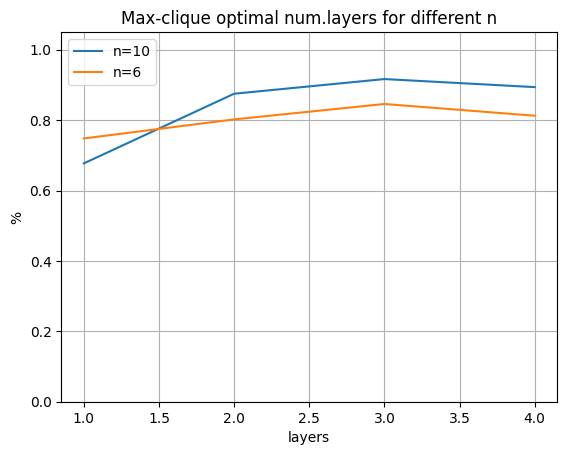

In [152]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_layers_n.json", ["layers", "n"], "Max-clique optimal num.layers for different n", fig_filename="Figures/qaoa_maxclique_layers_n")

[0.1  0.25 0.4  0.55]
[0.1  0.25 0.4  0.55]


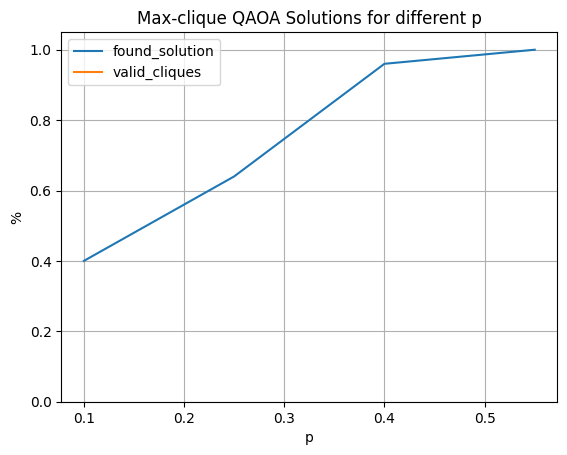

In [26]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p.json", ["p"], "Max-clique QAOA Solutions for different p", plots=["found_solution", "valid_cliques"])

[0.1 0.3 0.5 0.7]
[0.1 0.3 0.5 0.7]


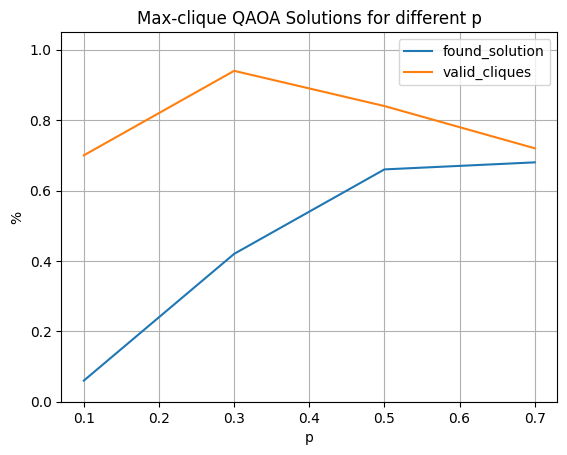

[0.1 0.3 0.5 0.7]
[0.1 0.3 0.5 0.7]


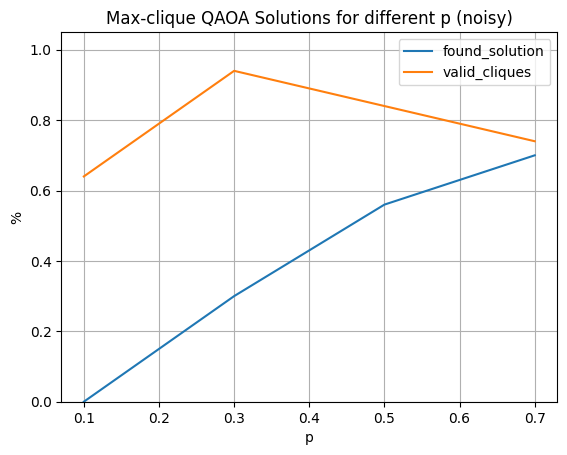

In [ ]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p_oneiter.json", ["p"], "Max-clique QAOA Solutions for different p", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_maxclique_p")
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p_oneiter_noisy.json", ["p"], "Max-clique QAOA Solutions for different p (noisy)", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_maxclique_p_noisy")

## Circuit depths

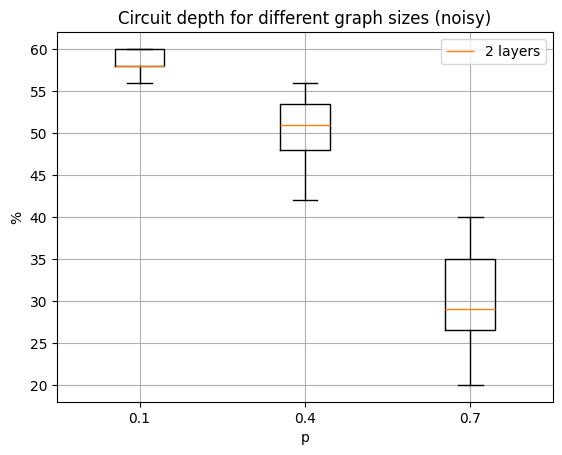

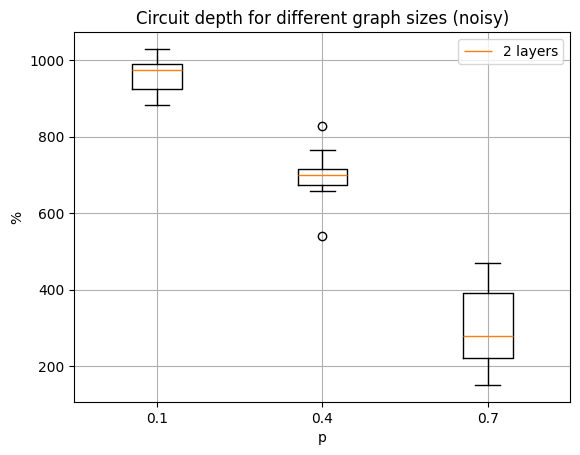

In [ ]:
plot_circuit_infos("benchmarkResults/qaoa_results_maxclique_p_oneiter.json", ["p"], "Circuit depth for different graph sizes (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_maxclique_p_depth")
# noisy
plot_circuit_infos("benchmarkResults/qaoa_results_maxclique_p_oneiter_noisy.json", ["p"], "Circuit depth for different graph sizes (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_maxclique_p_depth_noisy")

# QA

[ 6 11 16 21 26 31 36 41 46]
[ 6 11 16 21 26 31 36 41 46]


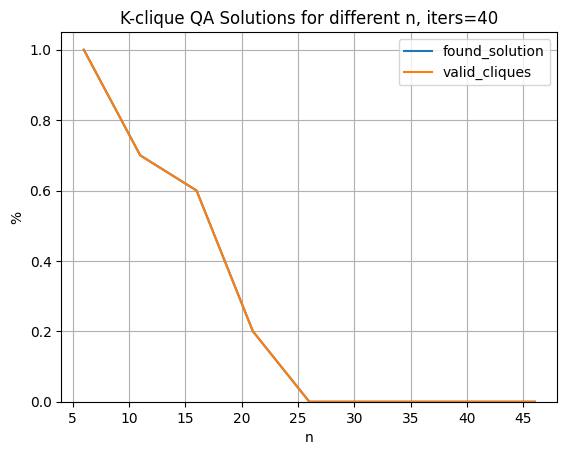

In [150]:
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_n.json", ["n"], "K-clique QA Solutions for different n, iters=40", plots=["found_solution", "valid_cliques"])

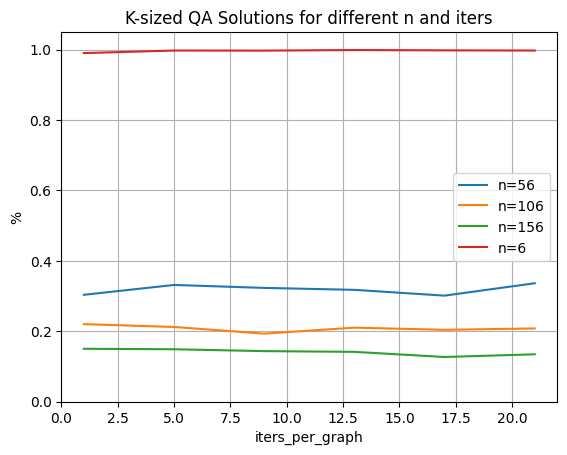

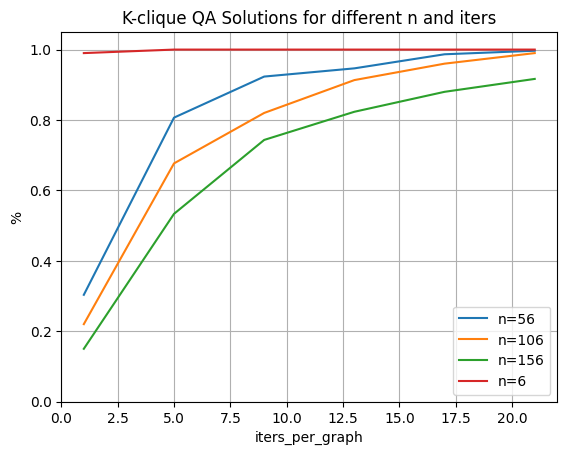

In [182]:
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n.json", ["iters_per_graph", "n"], "K-sized QA Solutions for different n and iters", 
                          plots=["is_size_k"], 
                          interpret_metric=["per_iter"],
                          fig_filename="Figures/qa_kclique_ksized_iters_n")
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n.json", ["iters_per_graph", "n"], "K-clique QA Solutions for different n and iters", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"],
                          fig_filename="Figures/qa_kclique_iters_n")

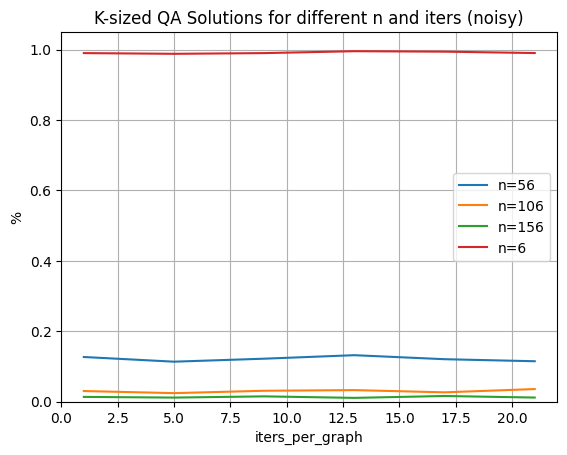

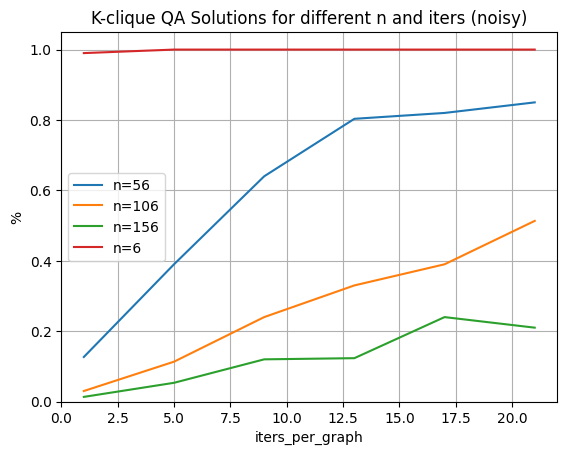

In [175]:
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n_noisy.json", ["iters_per_graph", "n"], "K-sized QA Solutions for different n and iters (noisy)", 
                          plots=["is_size_k"], 
                          interpret_metric=["per_iter"], 
                          fig_filename="Figures/qa_kclique_ksized_iters_n_noisy")
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n_noisy.json", ["iters_per_graph", "n"], "K-clique QA Solutions for different n and iters (noisy)", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"],
                          fig_filename="Figures/qa_kclique_iters_n_noisy")

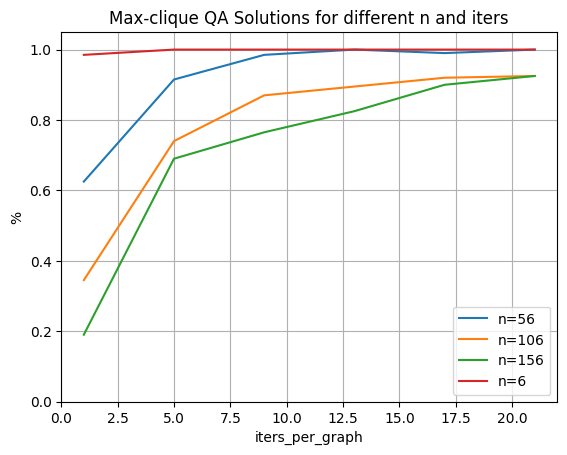

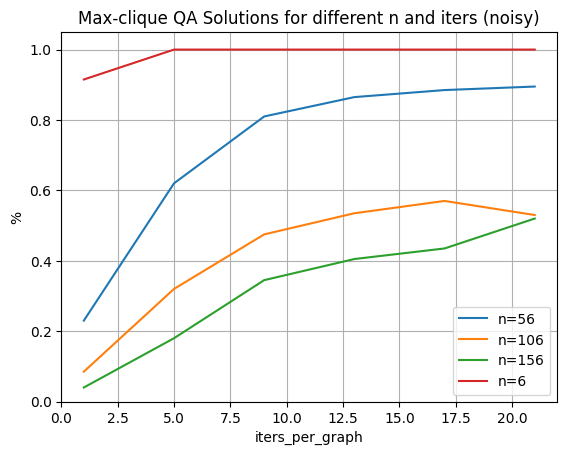

In [181]:
plot_success_prob_for_var("benchmarkResults/qa_results_maxclique_iters_n.json", ["iters_per_graph", "n"], "Max-clique QA Solutions for different n and iters", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"], 
                          fig_filename="Figures/qa_maxclique_iters_n")
plot_success_prob_for_var("benchmarkResults/qa_results_maxclique_iters_n_noisy.json", ["iters_per_graph", "n"], "Max-clique QA Solutions for different n and iters (noisy)", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"], 
                          fig_filename="Figures/qa_maxclique_iters_n_noisy")